In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset, DataLoader, random_split
from torchvision.datasets import SVHN
from torchvision.transforms import Compose, ToTensor, Normalize, Resize
import albumentations as A

In [2]:
class AlbumentationsWrapper:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image):
        image = np.array(image)
        augmented = self.transform(image=image)
        return augmented['image']

In [3]:
transform = AlbumentationsWrapper(A.Compose([
    A.RandomCrop(28,28),
    A.Rotate(limit=20, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Blur(blur_limit=3, p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
    A.Normalize(mean=(0.4377, 0.4438, 0.4728), std=(0.1980, 0.2010, 0.1970)),
    A.ToTensorV2()
]))

In [4]:
train = SVHN(
    root='data',
    download=True,
    split='train',
    transform=transform
)

test = SVHN(
    root='data',
    download=True,
    split='test',
    transform=Compose([
        Resize((28,28)),
        ToTensor(),
        Normalize(mean=(0.4377, 0.4438, 0.4728), std=(0.1980, 0.2010, 0.1970))
    ])
)

extra = SVHN(
    root='data',
    download=True,
    split='extra',
    transform=Compose([
        Resize((28,28)),
        ToTensor(),
        Normalize(mean=(0.4377, 0.4438, 0.4728), std=(0.1980, 0.2010, 0.1970))
    ])
)

In [5]:
train = ConcatDataset([train, extra])
train_size = int(0.85 * len(train))
val_size = len(train) - train_size

train, val = random_split(train, [train_size, val_size])
print('Training size: ', len(train))
print('Validation size: ', len(val))
print('Test size: ', len(test))

Training size:  513729
Validation size:  90659
Test size:  26032


In [6]:
train[0][0].shape

torch.Size([3, 28, 28])

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [8]:
loader_train  = DataLoader(dataset=train, shuffle=True, batch_size=512, pin_memory=True,
                            in_order=False, prefetch_factor=3, num_workers=8, persistent_workers=True)

loader_test  = DataLoader(dataset=test, batch_size=512, pin_memory=True, 
                          in_order=False, prefetch_factor=3, num_workers=8, persistent_workers=True)

loader_val  = DataLoader(dataset=val, batch_size=512, pin_memory=True, in_order=False,
                        prefetch_factor=3, num_workers=8, persistent_workers=True)

In [36]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=(3,3), padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=(3,3), padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.3),

            nn.Conv2d(32, 64, kernel_size=(3,3), padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.3),

            nn.Conv2d(64, 128, kernel_size=(3,3), padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(128)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, 32),
            nn.LeakyReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.3),
            
            nn.Linear(32, 10),
        )
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
                nn.init.zeros_(m.bias)

    def forward(self, X):
        X = self.features(X)
        return self.classifier(X)

In [37]:
model = BasicCNN().to(device)

In [12]:
from tqdm import trange

In [39]:
# Checking basic performance
epochs = 20
train_losses = []
val_losses = []

model.train()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

for _ in trange(epochs):
    train_loss_batch = 0
    val_loss_batch = 0
    
    for X,y in loader_train:
        X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        proba = model(X)
        
        loss = loss_fn(proba, y)

        train_loss_batch += loss.item()
        
        loss.backward()
        optimizer.step()

    train_losses.append(train_loss_batch / len(loader_train))

    #Validation loss
    with torch.no_grad():
        for X,y in loader_val:
            X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            proba = model(X)

            loss = loss_fn(proba, y)

            val_loss_batch += loss.item()

    val_losses.append(val_loss_batch / len(loader_val))

100%|██████████████████████████████████████████████████████████████████| 20/20 [07:49<00:00, 23.49s/it]


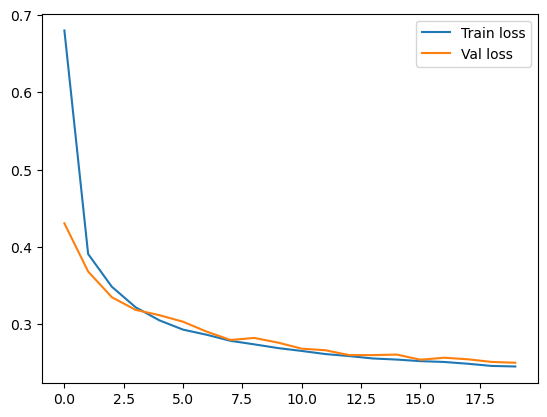

In [40]:
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.legend()
plt.show()

In [41]:
#Test accuracy:
model.eval()
correct_preds = 0
total_samples= 0

for X,y in loader_test:
    X,y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
    y_pred = model(X).argmax(dim=1)
    correct_preds += (y_pred == y).sum().item()
    total_samples += len(y)

accuracy = correct_preds / total_samples
print('Accuracy on test data: ', accuracy)

Accuracy on test data:  0.9227489244007375


### Trying with params obtained after 30 trials of optuna

{'n_conv_layers': 4, 'conv_layer0_filters': 128, 'conv_layer0_activation': 'leaky_relu', 'conv_layer0_dropout_p': 0.09250007788870405, 'conv_layer1_filters': 128, 'conv_layer1_activation': 'leaky_relu', 'conv_layer1_dropout_p': 0.24728441290253167, 'conv_layer2_filters': 128, 'conv_layer2_activation': 'leaky_relu', 'conv_layer2_dropout_p': 0.12619807815971934, 'conv_layer3_filters': 256, 'conv_layer3_activation': 'leaky_relu', 'conv_layer3_dropout_p': 0.015272635609429597, 'n_dense_layers': 2, 'dense_layer0_n_neurons': 32, 'dense_layer0_activation': 'leaky_relu', 'dense_layer0_batchnorm_used': False, 'dense_layer0_dropout_p': 0.07717497500203314, 'dense_layer1_n_neurons': 128, 'dense_layer1_activation': 'relu', 'dense_layer1_batchnorm_used': False, 'dense_layer1_dropout_p': 0.2285981936849122, 'lr': 0.002022709004756559, 'weight_decay': 1.8452942242597188e-05, 'optimizer': 'Adam', 'beta1': 0.7041827296589579, 'beta2': 0.9508489691222258}

In [9]:
class TunedModel1(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(128),
            nn.Dropout2d(0.1),

            nn.Conv2d(128, 128, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(128),
            nn.Dropout2d(0.25),

            nn.Conv2d(128, 128, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(128),
            nn.Dropout2d(0.125),

            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(256)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(2304, 32),
            nn.LeakyReLU(),
            nn.Dropout(0.8),

            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Dropout(0.23),

            nn.Linear(128, 10)
        )

    def forward(self, X):
        X = self.features(X)
        return self.classifier(X)

In [10]:
tuned_model_1 = TunedModel1().to(device)

In [21]:
from pathlib import Path

In [16]:
loss_fn = nn.CrossEntropyLoss()
tuned_optimiser = torch.optim.Adam(tuned_model_1.parameters(), lr=0.002, weight_decay=1.85e-5, betas=(0.7, 0.95))
epochs = 60
best_loss = float('inf')
patience = 10
counter = 0
min_delta = 1e-4

train_losses = []
val_losses = []

for epoch in trange(epochs, desc='Training', total=epochs):
    tuned_model_1.train()

    training_loss_epoch = 0
    for X, y in loader_train:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        tuned_optimiser.zero_grad()

        proba = tuned_model_1(X)
        loss = loss_fn(proba, y)
        training_loss_epoch += loss.item()
        
        loss.backward()
        tuned_optimiser.step()
    train_losses.append(training_loss_epoch / len(loader_train))


    
    # Early stopping
    tuned_model_1.eval()
    
    val_loss_epoch = 0
    for X, y in loader_val:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.no_grad():
            proba = tuned_model_1(X)
            val_loss_epoch += loss_fn(proba, y).item()
    val_losses.append(val_loss_epoch / len(loader_val))
    
    
    if val_loss_epoch < best_loss - min_delta:
        best_loss = val_loss_epoch
        best_epoch = epoch
        counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': tuned_model_1.state_dict(),
            'optimizer_state': tuned_optimiser.state_dict(),
            'best_loss': best_loss,
            'counter': counter
        }, 'checkpoint.pth')
    else:
        counter += 1
        if counter == patience:
            print(f'Early stopping triggered, validation loss has not improved after {patience} rounds.\nBest epoch: {best_epoch}\nBest loss: {best_loss}')
            break

    tuned_model_1.train()

Training:  25%|██████████████                                          | 15/60 [16:04<48:13, 64.30s/it]

Early stopping triggered, validation loss has not improved after 5 rounds.
Best epoch: 10
Best loss: 36.09931107610464


#### Completed training over a stretch of multiple sessions. Did not want system to heat up for too long.
#### Training took around two hours
Overall, ran for 47 epochs before early stopping was triggered (notebook says 10 because I was initially saving only the best model, not checkpoint.pth)

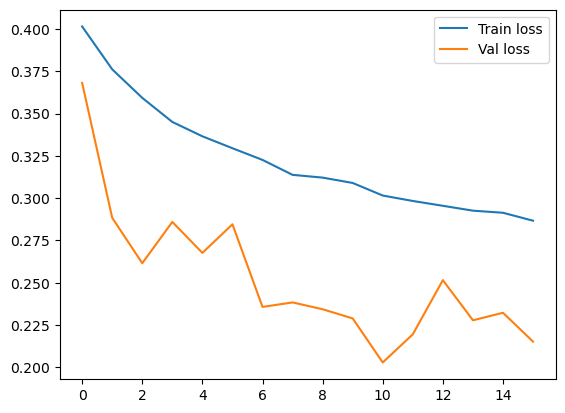

In [17]:
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.legend()
plt.show()

In [18]:
tuned_model_1.load_state_dict(torch.load('best.pth'))

<All keys matched successfully>

In [20]:
#testing on test dataset
correct_preds = 0
total_samples = 0

tuned_model_1.eval()
for X, y in loader_test:
    X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
    with torch.no_grad():
        preds = tuned_model_1(X).argmax(dim=1)
        correct_preds += (y == preds).sum().item()
        total_samples += len(y)

print('accuracy on test data: ', correct_preds / total_samples)

accuracy on test data:  0.9330823601720959


___
### Trying after Tuning for 80 trials

{'n_conv_layers': 4, 'conv_layer0_filters': 256, 'conv_layer0_activation': 'relu', 'conv_layer0_dropout_p': 0.30955955404945174, 'conv_layer1_filters': 64, 'conv_layer1_activation': 'leaky_relu', 'conv_layer1_dropout_p': 0.03182437370300047, 'conv_layer2_filters': 128, 'conv_layer2_activation': 'relu', 'conv_layer2_dropout_p': 0.1733690912844672, 'conv_layer3_filters': 256, 'conv_layer3_activation': 'relu', 'conv_layer3_dropout_p': 0.12006000160966604, 'n_dense_layers': 1, 'dense_layer0_n_neurons': 64, 'dense_layer0_activation': 'leaky_relu', 'dense_layer0_batchnorm_used': False, 'dense_layer0_dropout_p': 0.0196227780805927, 'lr': 0.003390458488258465, 'weight_decay': 4.0116457079723036e-05, 'optimizer': 'Adam', 'beta1': 0.761862031768956, 'beta2': 0.9402773952125457}

<br>
I still made some changes when making the model. For instance, instead of 256 -> 64 -> 128 -> 256 for number of filters for features part of the model, I went with 64 -> 128 -> 256 -> 256, also added AdaptiveAvgPool which I did not try in tuning

In [9]:
class TunedModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(64),
            nn.Dropout2d(0.3),

            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(128),
            nn.Dropout2d(0.05),

            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(256),
            nn.Dropout2d(0.2),

            nn.Conv2d(256, 256, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(256),
            nn.Dropout2d(0.1)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            
            nn.Linear(256, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, X):
        X = self.features(X)
        return self.classifier(X)

In [10]:
tuned_model_2 = TunedModel2().to(device)

In [11]:
loss_fn = nn.CrossEntropyLoss()
tuned_optimiser = torch.optim.Adam(tuned_model_2.parameters(), lr=0.0034, weight_decay=4.85e-5, betas=(0.75, 0.95))
epochs = 80
best_loss = float('inf')
patience = 10
counter = 0
min_delta = 1e-4

In [13]:
train_losses = []
val_losses = []

for epoch in trange(epochs, desc='Training', total=epochs):
    tuned_model_2.train()

    training_loss_epoch = 0
    for X, y in loader_train:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        tuned_optimiser.zero_grad()

        proba = tuned_model_2(X)
        loss = loss_fn(proba, y)
        training_loss_epoch += loss.item()
        
        loss.backward()
        tuned_optimiser.step()
    train_losses.append(training_loss_epoch / len(loader_train))


    
    # Early stopping
    tuned_model_2.eval()
    
    val_loss_epoch = 0
    for X, y in loader_val:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.no_grad():
            proba = tuned_model_2(X)
            val_loss_epoch += loss_fn(proba, y).item()
    val_loss_epoch /= len(loader_val)
    val_losses.append(val_loss_epoch)
    
    
    if val_loss_epoch < best_loss - min_delta:
        best_loss = val_loss_epoch
        best_epoch = epoch
        counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': tuned_model_2.state_dict(),
            'optimizer_state': tuned_optimiser.state_dict(),
            'best_loss': best_loss,
            'counter': counter
        }, 'checkpoint2.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping triggered, validation loss has not improved after {patience} rounds.\nBest epoch: {best_epoch}\nBest loss: {best_loss}')
            break

    tuned_model_2.train()

Training:  29%|████████████████                                        | 23/80 [18:12<45:07, 47.50s/it]

Early stopping triggered, validation loss has not improved after 10 rounds.
Best epoch: 13
Best loss: 0.10907759873217411


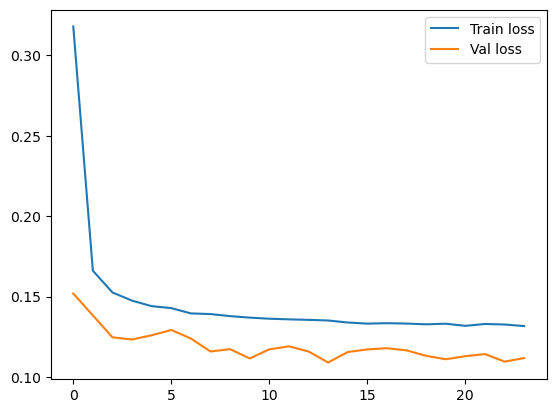

In [14]:
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.legend()
plt.show()

In [15]:
checkpoint2 = torch.load('checkpoint2.pth')
tuned_model_2.load_state_dict(checkpoint2['model_state'])

<All keys matched successfully>

In [16]:
#testing on test dataset
correct_preds = 0
total_samples = 0

tuned_model_2.eval()
for X, y in loader_test:
    X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
    with torch.no_grad():
        preds = tuned_model_2(X).argmax(dim=1)
        correct_preds += (y == preds).sum().item()
        total_samples += len(y)

print('accuracy on test data: ', correct_preds / total_samples)

accuracy on test data:  0.9522510755992625


### One last try because I have plenty time right now
Trying with one more layer with 256 filters

In [17]:
class TunedModel3(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(64),
            nn.Dropout2d(0.3),

            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(128),
            nn.Dropout2d(0.05),

            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(256),
            nn.Dropout2d(0.2),

            nn.Conv2d(256, 256, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(256),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, 256, kernel_size=3, padding='same'),
            nn.LeakyReLU(),
            nn.BatchNorm2d(256),
            nn.Dropout2d(0.1)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            
            nn.Linear(256, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, X):
        X = self.features(X)
        return self.classifier(X)

In [18]:
tuned_model_3 = TunedModel3().to(device)

In [19]:
loss_fn = nn.CrossEntropyLoss()
tuned_optimiser = torch.optim.Adam(tuned_model_3.parameters(), lr=0.0034, weight_decay=4.85e-5, betas=(0.75, 0.95))
epochs = 80
best_loss = float('inf')
patience = 10
counter = 0
min_delta = 1e-4

In [20]:
train_losses = []
val_losses = []

for epoch in trange(epochs, desc='Training', total=epochs):
    tuned_model_3.train()

    training_loss_epoch = 0
    for X, y in loader_train:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        tuned_optimiser.zero_grad()

        proba = tuned_model_3(X)
        loss = loss_fn(proba, y)
        training_loss_epoch += loss.item()
        
        loss.backward()
        tuned_optimiser.step()
    train_losses.append(training_loss_epoch / len(loader_train))


    
    # Early stopping
    tuned_model_3.eval()
    
    val_loss_epoch = 0
    for X, y in loader_val:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.no_grad():
            proba = tuned_model_3(X)
            val_loss_epoch += loss_fn(proba, y).item()
    val_loss_epoch /= len(loader_val)
    val_losses.append(val_loss_epoch)
    
    
    if val_loss_epoch < best_loss - min_delta:
        best_loss = val_loss_epoch
        best_epoch = epoch
        counter = 0
        torch.save({
            'epoch': epoch,
            'model_state': tuned_model_3.state_dict(),
            'optimizer_state': tuned_optimiser.state_dict(),
            'best_loss': best_loss,
            'counter': counter
        }, 'checkpoint2.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping triggered, validation loss has not improved after {patience} rounds.\nBest epoch: {best_epoch}\nBest loss: {best_loss}')
            break

    tuned_model_3.train()

Training:  50%|████████████████████████████                            | 40/80 [33:44<33:44, 50.62s/it]

Early stopping triggered, validation loss has not improved after 10 rounds.
Best epoch: 30
Best loss: 0.10532666278186809


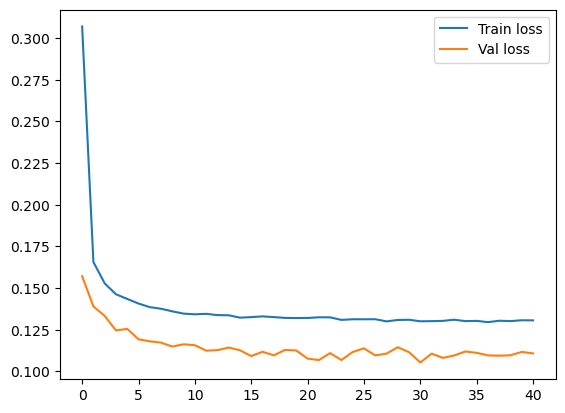

In [21]:
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.legend()
plt.show()

In [23]:
checkpoint2 = torch.load('checkpoint2.pth')
tuned_model_3.load_state_dict(checkpoint2['model_state'])

<All keys matched successfully>

In [24]:
#testing on test dataset
correct_preds = 0
total_samples = 0

tuned_model_3.eval()
for X, y in loader_test:
    X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
    with torch.no_grad():
        preds = tuned_model_3(X).argmax(dim=1)
        correct_preds += (y == preds).sum().item()
        total_samples += len(y)

print('accuracy on test data: ', correct_preds / total_samples)

accuracy on test data:  0.9543254456054088


In [25]:
torch.save(tuned_model_3.state_dict(), 'final_model.pt')